In [ ]:
import pandas as pd
import numpy as np

# Load the CSV file
file_path = '/content/drive/My Drive/Colab Notebooks/output_csv_file3.csv'
df = pd.read_csv(file_path)

# Ensure chronological order and sort by country_code and time
df['time'] = pd.to_datetime(df['time'], format='ISO8601')
df = df.sort_values(by=['country_code', 'time'])

# Create lagged features for the current speed and differences in other variables
for col in ['num_lane_instances_difference', 'num_vehicles_difference', 'num_vulnerable_vehicles_difference',
            'num_pedestrians_difference', 'num_traffic_lights_difference', 'num_traffic_signs_difference',
            'weather_condition_changed', 'road_type_changed', 'road_condition_changed', 'time_of_day_changed']:
    df[f'{col}_next'] = df.groupby('country_code')[col].shift(-1)

# Create the target variable for next frame's speed
df['next_speed_kmh'] = df.groupby('country_code')['average_speed_kmh'].shift(-1)

# Drop rows with NaN values created by shifting
df = df.dropna()

# Features and target variable
features = ['average_speed_kmh', 'num_lane_instances_difference_next', 'num_vehicles_difference_next',
            'num_vulnerable_vehicles_difference_next', 'num_pedestrians_difference_next',
            'num_traffic_lights_difference_next', 'num_traffic_signs_difference_next',
            'weather_condition_changed_next', 'road_type_changed_next', 'road_condition_changed_next',
            'time_of_day_changed_next']

X = df[features]
y = df['next_speed_kmh']

# Save the updated DataFrame to a new CSV file
output_file_path = '/content/drive/My Drive/processed_data.csv'
df.to_csv(output_file_path, index=False)


Epoch 1/100
2000/2000 [==============================] - 10s 3ms/step - loss: 289.8154 - mae: 11.4746 - val_loss: 241.6349 - val_mae: 10.4060
Epoch 2/100
2000/2000 [==============================] - 5s 3ms/step - loss: 230.6205 - mae: 10.6030 - val_loss: 223.6141 - val_mae: 10.3167
Epoch 3/100
2000/2000 [==============================] - 4s 2ms/step - loss: 221.8325 - mae: 10.4995 - val_loss: 217.7480 - val_mae: 10.2203
Epoch 4/100
2000/2000 [==============================] - 6s 3ms/step - loss: 215.8647 - mae: 10.3802 - val_loss: 213.6184 - val_mae: 10.4178
Epoch 5/100
2000/2000 [==============================] - 5s 2ms/step - loss: 212.7274 - mae: 10.2773 - val_loss: 212.5922 - val_mae: 10.1998
Epoch 6/100
2000/2000 [==============================] - 4s 2ms/step - loss: 210.6782 - mae: 10.2124 - val_loss: 213.4418 - val_mae: 10.5509
Epoch 7/100
2000/2000 [==============================] - 6s 3ms/step - loss: 209.0049 - mae: 10.1686 - val_loss: 211.7758 - val_mae: 9.9540
Epoch 8/100
2

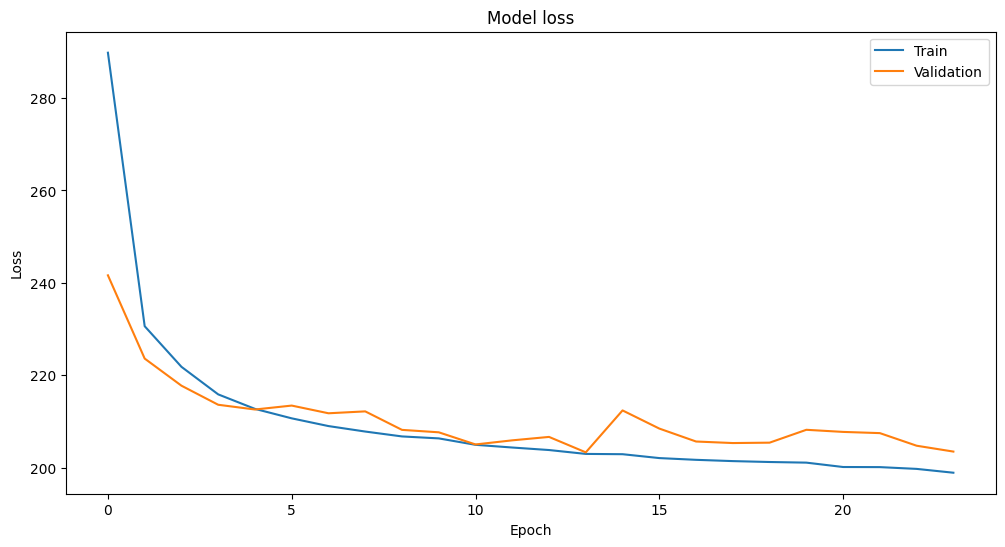

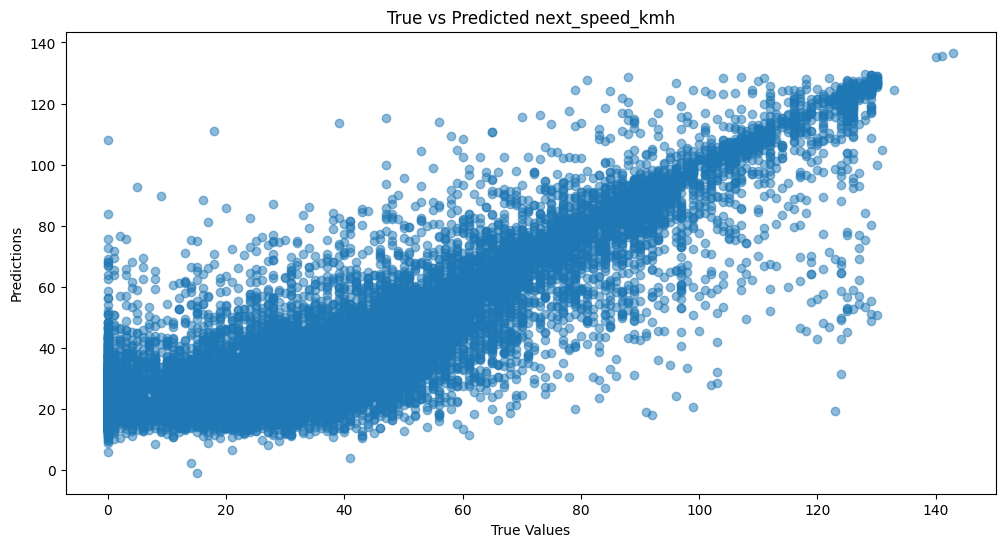

In [ ]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Load the processed data
processed_df = pd.read_csv('/content/drive/My Drive/processed_data.csv')

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Train the model with early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=32, callbacks=[early_stopping])

# Evaluate the model on the test set
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f'Test MAE: {test_mae}')

# Make predictions
y_pred = model.predict(X_test)

# Calculate R^2 Score
r2 = r2_score(y_test, y_pred)
print(f'R^2 Score: {r2}')

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

# Plot True vs Predicted values
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.title('True vs Predicted next_speed_kmh')
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.show()


Epoch 1/100
2000/2000 [==============================] - 9s 3ms/step - loss: 451.8105 - mae: 14.3062 - val_loss: 251.7073 - val_mae: 10.9395
Epoch 2/100
2000/2000 [==============================] - 9s 5ms/step - loss: 241.6293 - mae: 10.7800 - val_loss: 241.1192 - val_mae: 10.5037
Epoch 3/100
2000/2000 [==============================] - 7s 4ms/step - loss: 236.7642 - mae: 10.7173 - val_loss: 242.5048 - val_mae: 10.4887
Epoch 4/100
2000/2000 [==============================] - 9s 4ms/step - loss: 235.4828 - mae: 10.6982 - val_loss: 238.2810 - val_mae: 10.3850
Epoch 5/100
2000/2000 [==============================] - 7s 4ms/step - loss: 233.8591 - mae: 10.6548 - val_loss: 234.4175 - val_mae: 10.5210
Epoch 6/100
2000/2000 [==============================] - 8s 4ms/step - loss: 232.7854 - mae: 10.6254 - val_loss: 234.6556 - val_mae: 10.7719
Epoch 7/100
2000/2000 [==============================] - 7s 3ms/step - loss: 231.9854 - mae: 10.6028 - val_loss: 238.3281 - val_mae: 11.2150
Epoch 8/100
2

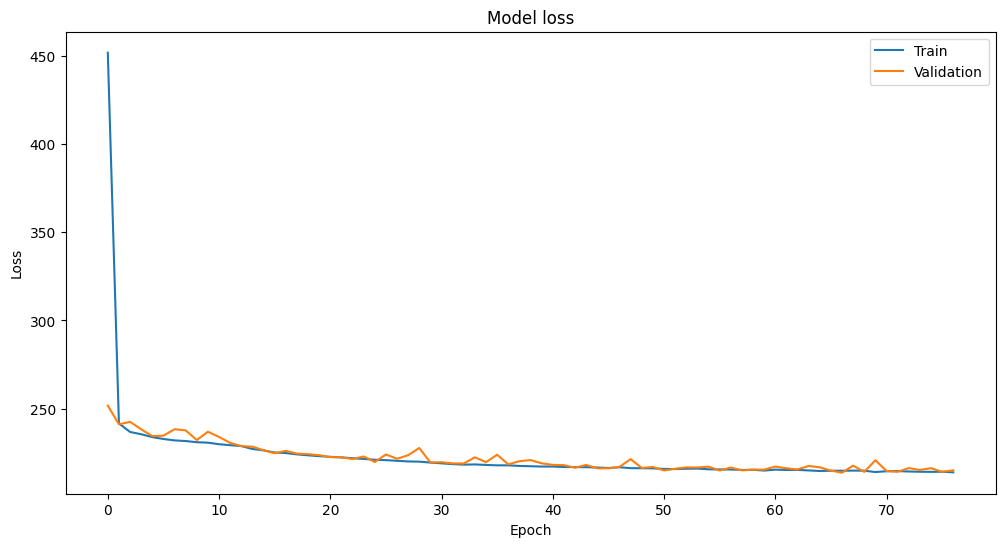

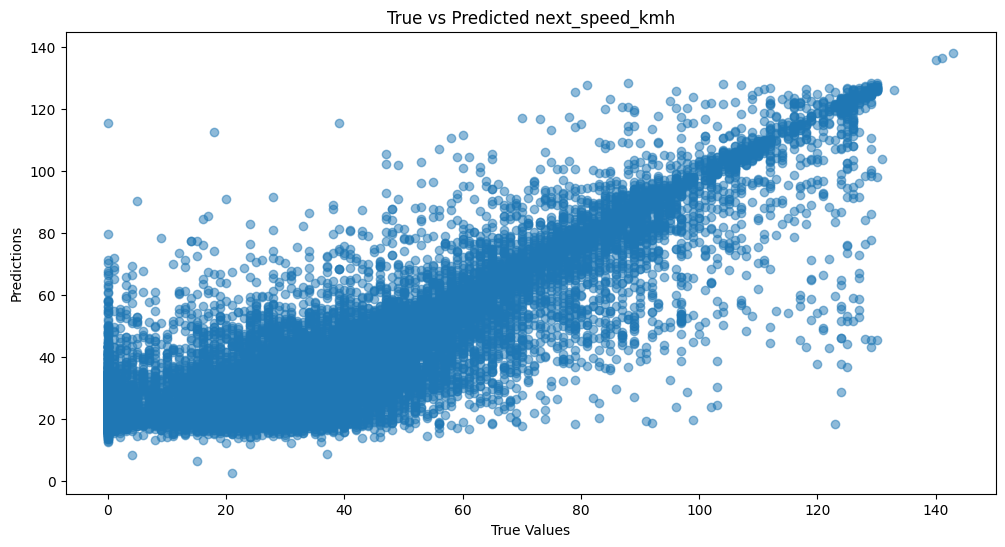

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Load the processed data
processed_df = pd.read_csv('/content/drive/My Drive/processed_data.csv')

# Normalize the features
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(processed_df[features])

# Reshape data for LSTM [samples, timesteps, features]
X = scaled_features.reshape((scaled_features.shape[0], 1, scaled_features.shape[1]))
y = processed_df['next_speed_kmh'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the LSTM model
model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Train the model with early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=32, callbacks=[early_stopping])

# Evaluate the model on the test set
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f'Test MAE: {test_mae}')

# Make predictions
y_pred = model.predict(X_test)

# Calculate R^2 Score
r2 = r2_score(y_test, y_pred)
print(f'R^2 Score: {r2}')

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

# Plot True vs Predicted values
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.title('True vs Predicted next_speed_kmh')
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.show()


Epoch 1/100
2000/2000 [==============================] - 10s 4ms/step - loss: 461.6452 - mae: 14.4893 - val_loss: 273.5745 - val_mae: 11.6704
Epoch 2/100
2000/2000 [==============================] - 7s 4ms/step - loss: 282.1269 - mae: 11.4552 - val_loss: 268.7268 - val_mae: 11.5375
Epoch 3/100
2000/2000 [==============================] - 8s 4ms/step - loss: 279.0775 - mae: 11.3869 - val_loss: 269.3130 - val_mae: 11.5931
Epoch 4/100
2000/2000 [==============================] - 8s 4ms/step - loss: 278.0458 - mae: 11.3644 - val_loss: 265.0974 - val_mae: 11.2935
Epoch 5/100
2000/2000 [==============================] - 7s 4ms/step - loss: 277.3055 - mae: 11.3426 - val_loss: 264.5914 - val_mae: 11.2250
Epoch 6/100
2000/2000 [==============================] - 8s 4ms/step - loss: 277.4004 - mae: 11.3482 - val_loss: 267.4668 - val_mae: 11.7565
Epoch 7/100
2000/2000 [==============================] - 8s 4ms/step - loss: 277.0784 - mae: 11.3349 - val_loss: 265.4379 - val_mae: 10.8787
Epoch 8/100


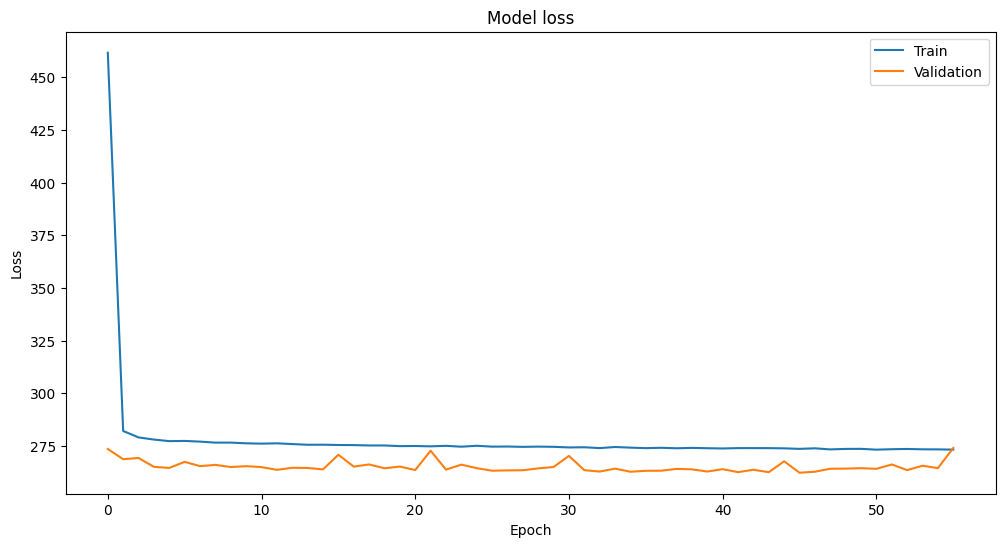

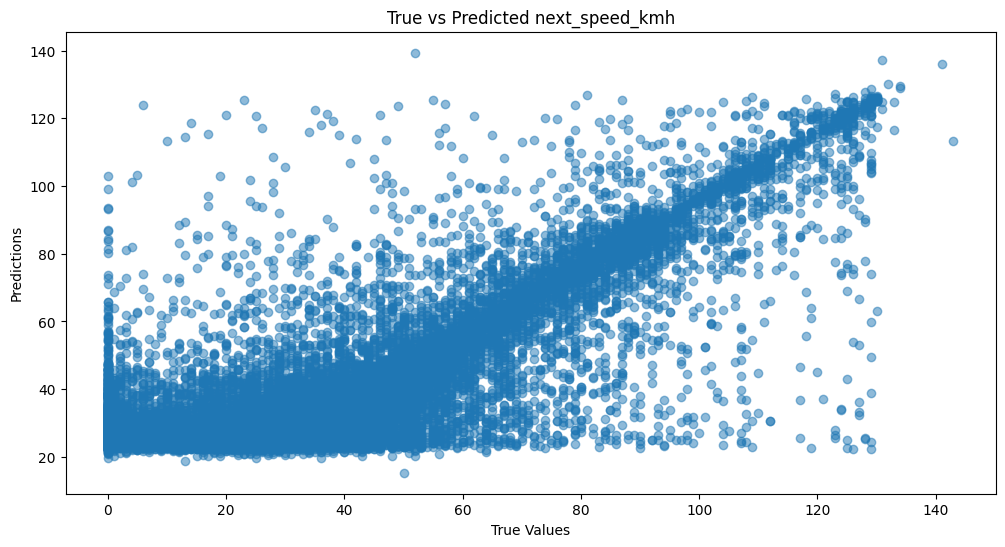

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Load the processed data
processed_df = pd.read_csv('/content/drive/My Drive/processed_data.csv')

# Convert 'time' column to datetime format and sort by country_code and time
processed_df['time'] = pd.to_datetime(processed_df['time'], format='ISO8601')
processed_df = processed_df.sort_values(by=['country_code', 'time'])

# Calculate differences for numerical columns and changes for categorical columns
numerical_columns = ['num_lane_instances', 'num_vehicles', 'num_vulnerable_vehicles', 'num_pedestrians', 'num_traffic_lights', 'num_traffic_signs']
categorical_columns = ['weather_condition', 'road_type', 'road_condition', 'time_of_day']

for col in numerical_columns:
    processed_df[f'{col}_difference'] = processed_df.groupby('country_code')[col].diff()

def detect_changes(x):
    return x != x.shift()

for col in categorical_columns:
    processed_df[f'{col}_changed'] = processed_df.groupby('country_code')[col].transform(detect_changes).astype(int)

# Drop the first row of each group because they will have NaN differences
processed_df.dropna(subset=[f'{col}_difference' for col in numerical_columns], inplace=True)

# Define features and target variable
features = [f'{col}_difference' for col in numerical_columns] + [f'{col}_changed' for col in categorical_columns] + ['average_speed_kmh']
target = 'next_speed_kmh'

# Create a new column for the target variable (next frame's speed)
processed_df[target] = processed_df.groupby('country_code')['average_speed_kmh'].shift(-1)

# Drop rows with NaN target values
processed_df.dropna(subset=[target], inplace=True)

# Normalize the features
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(processed_df[features])

# Reshape data for LSTM [samples, timesteps, features]
X = scaled_features.reshape((scaled_features.shape[0], 1, scaled_features.shape[1]))
y = processed_df[target].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the LSTM model
model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Train the model with early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=32, callbacks=[early_stopping])

# Evaluate the model on the test set
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f'Test MAE: {test_mae}')

# Make predictions
y_pred = model.predict(X_test)

# Calculate R^2 Score
r2 = r2_score(y_test, y_pred)
print(f'R^2 Score: {r2}')

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

# Plot True vs Predicted values
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.title('True vs Predicted next_speed_kmh')
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.show()


Index(['frame_id', 'time', 'country_code', 'weather_condition',
       'collection_car', 'road_type', 'road_condition', 'time_of_day',
       'num_lane_instances', 'num_vehicles', 'num_vulnerable_vehicles',
       'num_pedestrians', 'num_traffic_lights', 'num_traffic_signs',
       'longitude', 'latitude', 'solar_angle_elevation', 'average_speed',
       'time_span', 'average_speed_kmh', 'speed_difference',
       'num_lane_instances_difference', 'num_vehicles_difference',
       'num_vulnerable_vehicles_difference', 'num_pedestrians_difference',
       'num_traffic_lights_difference', 'num_traffic_signs_difference',
       'weather_condition_changed', 'road_type_changed',
       'road_condition_changed', 'time_of_day_changed',
       'num_lane_instances_difference_next', 'num_vehicles_difference_next',
       'num_vulnerable_vehicles_difference_next',
       'num_pedestrians_difference_next', 'num_traffic_lights_difference_next',
       'num_traffic_signs_difference_next', 'weather_co

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

        0-10       0.28      0.01      0.01      1960
       10-20       0.00      0.00      0.00      1555
       20-30       0.58      0.72      0.64       503
       30-40       0.55      0.20      0.29       222
       40-50       0.72      0.86      0.78       478
       50-60       0.00      0.00      0.00         8
       60-70       0.00      0.00      0.00         2
       70-80       0.31      0.64      0.42      3078
       80-90       0.43      0.48      0.45      4011
      90-100       0.48      0.45      0.47      3194
     100-110       0.46      0.41      0.44      1594
     110-120       0.48      0.47      0.48      1149
     120-130       0.46      0.47      0.47       796
     130-140       0.54      0.65      0.59       942
     140-150       0.54      0.34      0.42       499

    accuracy                           0.43     19991
   macro avg       0.39      0.38      0.36     19991
weighted avg       0.40   

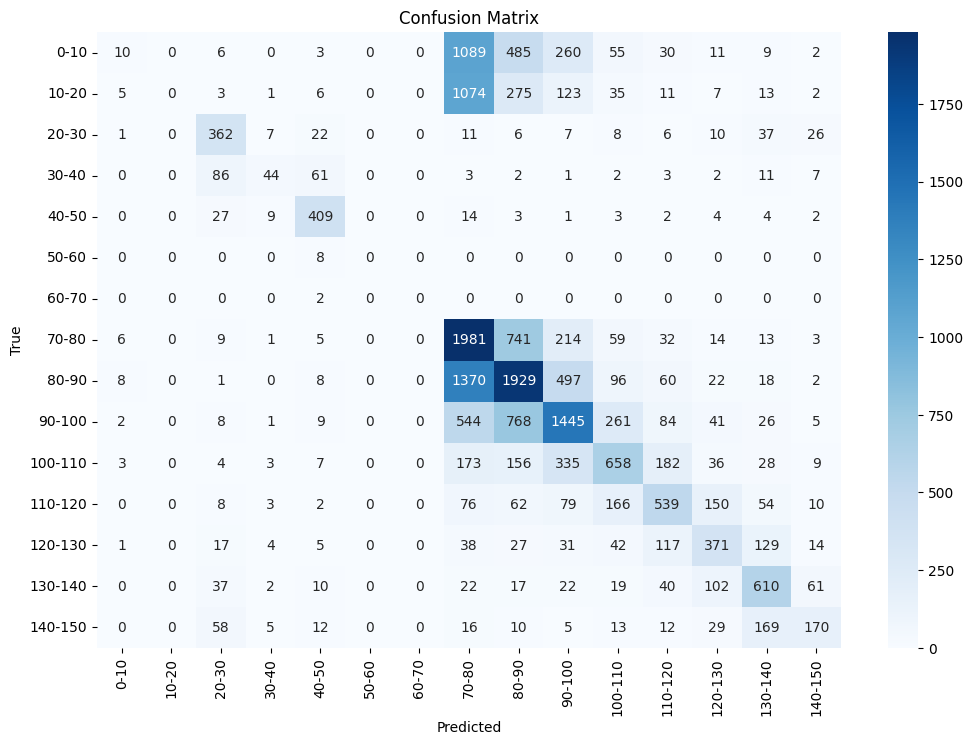

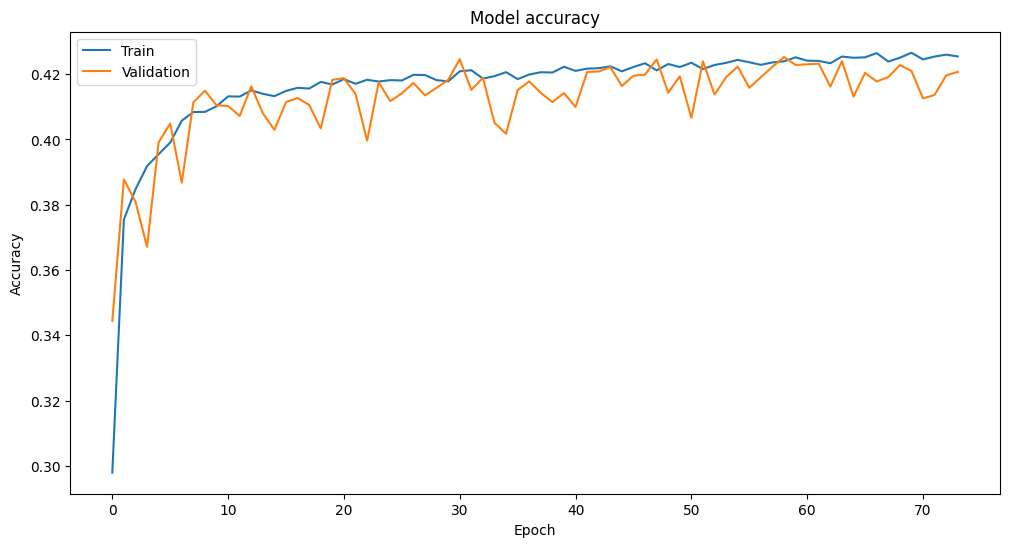

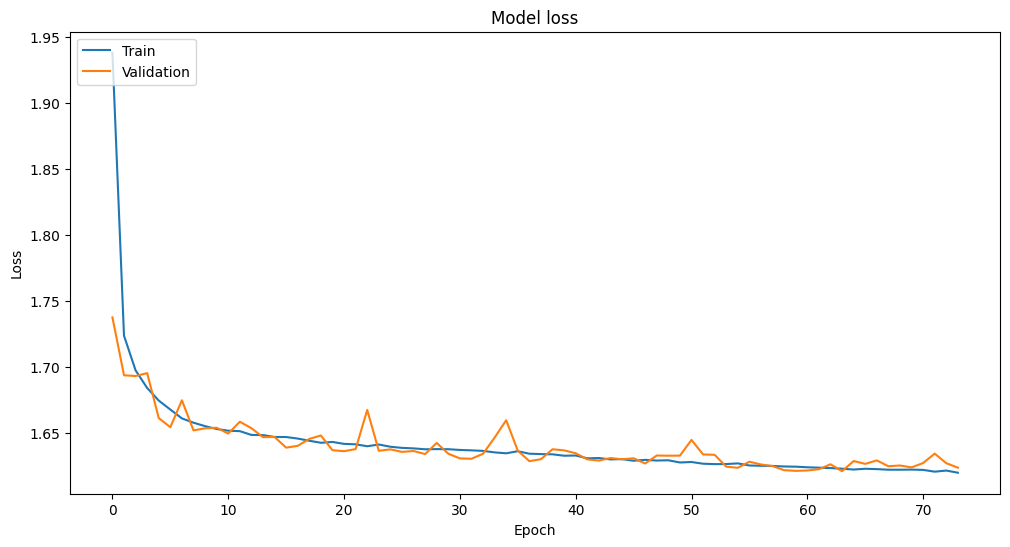

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

# Load the processed data
processed_df = pd.read_csv('/content/drive/My Drive/processed_data.csv')

# Print column names to verify the correct column names
print(processed_df.columns)

# Convert 'time' column to datetime format and sort by country_code and time
processed_df['time'] = pd.to_datetime(processed_df['time'], format='ISO8601')
processed_df = processed_df.sort_values(by=['country_code', 'time'])

# Calculate differences for numerical columns and changes for categorical columns
numerical_columns = ['num_lane_instances', 'num_vehicles', 'num_vulnerable_vehicles', 'num_pedestrians', 'num_traffic_lights', 'num_traffic_signs']
categorical_columns = ['weather_condition', 'road_type', 'road_condition', 'time_of_day']

for col in numerical_columns:
    processed_df[f'{col}_difference'] = processed_df.groupby('country_code')[col].diff()

def detect_changes(x):
    return x != x.shift()

for col in categorical_columns:
    processed_df[f'{col}_changed'] = processed_df.groupby('country_code')[col].transform(detect_changes).astype(int)

# Drop the first row of each group because they will have NaN differences
processed_df.dropna(subset=[f'{col}_difference' for col in numerical_columns], inplace=True)

# Define features and target variable
features = [f'{col}_difference' for col in numerical_columns] + [f'{col}_changed' for col in categorical_columns] + ['average_speed_kmh']
target = 'next_speed_bin'

# Create bins for the average_speed_kmh
bins = np.arange(0, processed_df['average_speed_kmh'].max() + 10, 10)
labels = [f'{int(bins[i])}-{int(bins[i+1])}' for i in range(len(bins)-1)]
processed_df['speed_bin'] = pd.cut(processed_df['average_speed_kmh'], bins=bins, labels=labels, include_lowest=True)

# Create a new column for the target variable (next frame's speed bin)
processed_df[target] = processed_df.groupby('country_code')['speed_bin'].shift(-1)

# Drop rows with NaN target values
processed_df.dropna(subset=[target], inplace=True)

# Encode the target labels
label_encoder = LabelEncoder()
processed_df[target] = label_encoder.fit_transform(processed_df[target])

# Normalize the features
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(processed_df[features])

# Reshape data for LSTM [samples, timesteps, features]
X = scaled_features.reshape((scaled_features.shape[0], 1, scaled_features.shape[1]))
y = processed_df[target].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the LSTM model
model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(len(labels), activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model with early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=32, callbacks=[early_stopping])

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {test_accuracy}')

# Make predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Calculate classification metrics
print(classification_report(y_test, y_pred_classes, target_names=labels))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [ ]:
import pandas as pd

# Load the CSV file
file_path = '/content/drive/My Drive/Colab Notebooks/output_csv_file3.csv'
df = pd.read_csv(file_path)

# Display the first few rows of the DataFrame
df.head()


,frame_id,time,country_code,weather_condition,collection_car,road_type,road_condition,time_of_day,num_lane_instances,num_vehicles,...,num_lane_instances_difference,num_vehicles_difference,num_vulnerable_vehicles_difference,num_pedestrians_difference,num_traffic_lights_difference,num_traffic_signs_difference,weather_condition_changed,road_type_changed,road_condition_changed,time_of_day_changed
0,70724,2021-10-09 14:54:08.889815+00:00,CZ,clear-day,golf,highway,normal,day,3,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
1,56170,2021-10-09 14:54:16.779060+00:00,CZ,clear-day,golf,highway,normal,day,3,2,...,0.0,1.0,0.0,0.0,0.0,9.0,0,0,0,0
2,69977,2021-10-09 14:54:24.106971+00:00,CZ,clear-day,golf,highway,normal,day,3,1,...,0.0,-1.0,0.0,0.0,0.0,-8.0,0,0,0,0
3,56874,2021-10-09 14:54:32.887522+00:00,CZ,clear-day,golf,highway,normal,day,3,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
4,57687,2021-10-09 14:56:56.443567+00:00,CZ,clear-day,golf,highway,normal,day,4,1,...,1.0,0.0,0.0,0.0,1.0,0.0,0,0,0,0


In [ ]:
# Ensure that the categorical changes are treated as numerical (0 or 1)
categorical_columns = ['weather_condition_changed', 'road_type_changed', 'road_condition_changed', 'time_of_day_changed']

# Fill any missing values if necessary
df.fillna(0, inplace=True)

# Features and target variable
features = ['num_lane_instances_difference', 'num_vehicles_difference', 'num_vulnerable_vehicles_difference',
            'num_pedestrians_difference', 'num_traffic_lights_difference', 'num_traffic_signs_difference',
            'weather_condition_changed', 'road_type_changed', 'road_condition_changed', 'time_of_day_changed',
            'speed_difference']

X = df[features]
y = df['average_speed_kmh']


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# Define the model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Train the model with early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=32, callbacks=[early_stopping])


Epoch 1/100
2000/2000 [==============================] - 6s 2ms/step - loss: 735.1493 - mae: 19.6567 - val_loss: 405.2357 - val_mae: 15.2463
Epoch 2/100
2000/2000 [==============================] - 4s 2ms/step - loss: 380.4831 - mae: 14.7094 - val_loss: 355.7536 - val_mae: 14.1698
Epoch 3/100
2000/2000 [==============================] - 6s 3ms/step - loss: 356.6614 - mae: 14.0865 - val_loss: 357.5851 - val_mae: 14.0071
Epoch 4/100
2000/2000 [==============================] - 4s 2ms/step - loss: 349.6278 - mae: 13.8824 - val_loss: 334.0256 - val_mae: 13.5719
Epoch 5/100
2000/2000 [==============================] - 4s 2ms/step - loss: 344.9204 - mae: 13.7743 - val_loss: 331.0027 - val_mae: 13.5097
Epoch 6/100
2000/2000 [==============================] - 7s 3ms/step - loss: 341.1413 - mae: 13.6790 - val_loss: 328.8133 - val_mae: 13.5512
Epoch 7/100
2000/2000 [==============================] - 5s 3ms/step - loss: 340.2830 - mae: 13.6749 - val_loss: 332.2080 - val_mae: 13.5440
Epoch 8/100
2

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = '/content/drive/My Drive/Colab Notebooks/output_csv_file3.csv'
df = pd.read_csv(file_path)

# Convert 'time' column to datetime format and sort by country_code and time
df['time'] = pd.to_datetime(df['time'], format='ISO8601')
df = df.sort_values(by=['country_code', 'time'])

# Calculate differences for numerical columns and changes for categorical columns
numerical_columns = ['num_lane_instances', 'num_vehicles', 'num_vulnerable_vehicles', 'num_pedestrians', 'num_traffic_lights', 'num_traffic_signs']
categorical_columns = ['weather_condition', 'road_type', 'road_condition', 'time_of_day']

for col in numerical_columns:
    df[f'{col}_difference'] = df.groupby('country_code')[col].diff()

def detect_changes(x):
    return x != x.shift()

for col in categorical_columns:
    df[f'{col}_changed'] = df.groupby('country_code')[col].transform(detect_changes).astype(int)

# Drop the first row of each group because they will have NaN differences
df.dropna(subset=[f'{col}_difference' for col in numerical_columns], inplace=True)

# Function to train and evaluate model for each road type
def train_and_evaluate_model(df, road_type):
    # Filter the data for the given road type
    road_type_df = df[df['road_type'] == road_type]

    # Define features and target variable
    features = [f'{col}_difference' for col in numerical_columns] + [f'{col}_changed' for col in categorical_columns] + ['average_speed_kmh']
    target = 'next_speed_bin'

    # Create bins for the average_speed_kmh
    bins = np.arange(0, df['average_speed_kmh'].max() + 10, 10)
    labels = [f'{int(bins[i])}-{int(bins[i+1])}' for i in range(len(bins)-1)]
    road_type_df['speed_bin'] = pd.cut(road_type_df['average_speed_kmh'], bins=bins, labels=labels, include_lowest=True)

    # Create a new column for the target variable (next frame's speed bin)
    road_type_df[target] = road_type_df.groupby('country_code')['speed_bin'].shift(-1)

    # Drop rows with NaN target values
    road_type_df.dropna(subset=[target], inplace=True)

    # Encode the target labels
    label_encoder = LabelEncoder()
    road_type_df[target] = label_encoder.fit_transform(road_type_df[target])

    # Normalize the features
    scaler = MinMaxScaler()
    scaled_features = scaler.fit_transform(road_type_df[features])

    # Reshape data for LSTM [samples, timesteps, features]
    X = scaled_features.reshape((scaled_features.shape[0], 1, scaled_features.shape[1]))
    y = road_type_df[target].values

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Define the LSTM model
    model = Sequential()
    model.add(LSTM(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(len(labels), activation='softmax'))

    # Compile the model
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Train the model with early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=32, callbacks=[early_stopping])

    # Evaluate the model on the test set
    test_loss, test_accuracy = model.evaluate(X_test, y_test)
    print(f'Road Type: {road_type}, Test Accuracy: {test_accuracy}')

    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Calculate classification metrics
    print(classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix for {road_type}')
    plt.show()

    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'Model accuracy for {road_type}')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

    # Plot training & validation loss values
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'Model loss for {road_type}')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

# Split the dataset by road_type and train models for each road type
road_types = df['road_type'].unique()
for road_type in road_types:
    train_and_evaluate_model(df, road_type)


<ipython-input-5-7b644e5bbee5>:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  road_type_df['speed_bin'] = pd.cut(road_type_df['average_speed_kmh'], bins=bins, labels=labels, include_lowest=True)
<ipython-input-5-7b644e5bbee5>:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  road_type_df[target] = road_type_df.groupby('country_code')['speed_bin'].shift(-1)
<ipython-input-5-7b644e5bbee5>:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the 

Epoch 1/100
221/221 [==============================] - 3s 5ms/step - loss: 2.1867 - accuracy: 0.2249 - val_loss: 2.0346 - val_accuracy: 0.2015
Epoch 2/100
221/221 [==============================] - 1s 3ms/step - loss: 1.8988 - accuracy: 0.3304 - val_loss: 1.7520 - val_accuracy: 0.3848
Epoch 3/100
221/221 [==============================] - 1s 4ms/step - loss: 1.6204 - accuracy: 0.4620 - val_loss: 1.5907 - val_accuracy: 0.4856
Epoch 4/100
221/221 [==============================] - 1s 3ms/step - loss: 1.5365 - accuracy: 0.5094 - val_loss: 1.5428 - val_accuracy: 0.4924
Epoch 5/100
221/221 [==============================] - 1s 3ms/step - loss: 1.4979 - accuracy: 0.5178 - val_loss: 1.4938 - val_accuracy: 0.5110
Epoch 6/100
221/221 [==============================] - 1s 4ms/step - loss: 1.4641 - accuracy: 0.5264 - val_loss: 1.4853 - val_accuracy: 0.5133
Epoch 7/100
221/221 [==============================] - 1s 3ms/step - loss: 1.4367 - accuracy: 0.5312 - val_loss: 1.4519 - val_accuracy: 0.5224

ValueError: Number of classes, 14, does not match size of target_names, 15. Try specifying the labels parameter

In [ ]:
import pandas as pd
import os
import numpy as np

# Directory containing continuous path CSV files
path_dir = '/content/drive/My Drive/Colab Notebooks/ContinuousPaths'

# List all CSV files in the directory
path_files = [os.path.join(path_dir, f) for f in os.listdir(path_dir) if f.endswith('.csv')]

# Analyze the path lengths
path_lengths = [len(pd.read_csv(file)) for file in path_files]
print(f"Number of continuous paths: {len(path_lengths)}")
print(f"Average path length: {np.mean(path_lengths)}")
print(f"Median path length: {np.median(path_lengths)}")
print(f"Path length standard deviation: {np.std(path_lengths)}")


Number of continuous paths: 1243
Average path length: 21.117457763475464
Median path length: 11.0
Path length standard deviation: 31.551294623370467


In [ ]:
import pandas as pd
import os

def create_features(path_df):
    features = []
    for i in range(len(path_df) - 1):
        current_frame = path_df.iloc[i]
        next_frame = path_df.iloc[i + 1]

        feature_row = {
            'current_speed': current_frame['average_speed_kmh'],
            'next_speed': next_frame['average_speed_kmh'],
            'num_vehicles_difference': next_frame['num_vehicles'] - current_frame['num_vehicles'],
            'num_traffic_lights_difference': next_frame['num_traffic_lights'] - current_frame['num_traffic_lights'],
            'num_pedestrians_difference': next_frame['num_pedestrians'] - current_frame['num_pedestrians'],
            'time_difference_seconds': (next_frame['time'] - current_frame['time']).total_seconds(),
            # Add other relevant feature differences
        }
        features.append(feature_row)
    return pd.DataFrame(features)

# Create a combined DataFrame with all features
all_features = []
for file in path_files:
    path_df = pd.read_csv(file)
    path_df['time'] = pd.to_datetime(path_df['time'], format='ISO8601')
    features_df = create_features(path_df)
    all_features.append(features_df)

combined_features_df = pd.concat(all_features, ignore_index=True)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Prepare data
X = combined_features_df.drop(columns=['next_speed'])
y = combined_features_df['next_speed']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for LSTM
X_train_scaled = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

# Define LSTM model
model = Sequential()
model.add(LSTM(50, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Train the model
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=64, validation_split=0.2, verbose=1)

# Evaluate the model
y_pred = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MAE: {mae}")
print(f"R² Score: {r2}")


Epoch 1/100
251/251 [==============================] - 7s 8ms/step - loss: 1753.0098 - mae: 37.5098 - val_loss: 1536.3551 - val_mae: 35.0538
Epoch 2/100
251/251 [==============================] - 1s 6ms/step - loss: 1220.7668 - mae: 31.2907 - val_loss: 927.4998 - val_mae: 27.1724
Epoch 3/100
251/251 [==============================] - 1s 4ms/step - loss: 699.2964 - mae: 23.3852 - val_loss: 520.8004 - val_mae: 19.7912
Epoch 4/100
251/251 [==============================] - 1s 3ms/step - loss: 399.0818 - mae: 16.9005 - val_loss: 319.8824 - val_mae: 14.5381
Epoch 5/100
251/251 [==============================] - 1s 3ms/step - loss: 267.6294 - mae: 12.8651 - val_loss: 246.0515 - val_mae: 11.8297
Epoch 6/100
251/251 [==============================] - 1s 3ms/step - loss: 225.6735 - mae: 11.1848 - val_loss: 226.6673 - val_mae: 11.0030
Epoch 7/100
251/251 [==============================] - 1s 3ms/step - loss: 215.4887 - mae: 10.7265 - val_loss: 222.0187 - val_mae: 10.7916
Epoch 8/100
251/251 [===

In [ ]:
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import confusion_matrix, classification_report

# Bin the speed values
bins = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform')
y_binned = bins.fit_transform(y.values.reshape(-1, 1)).astype(int).reshape(-1)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_binned, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a classifier (e.g., RandomForest)
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train_scaled, y_train)

# Evaluate the classifier
y_pred = classifier.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print("Confusion Matrix:")
print(cm)
print("Classification Report:")
print(cr)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


Confusion Matrix:
[[161  94 137  91  24   1   0   0   0   0]
 [ 92 181 238  92  23   3   1   0   0   0]
 [108 168 603 301  42   9   1   0   0   0]
 [ 65  55 251 905 169  12   4   1   0   1]
 [ 19  14  59 192 440  51   5   0   0   0]
 [  4   0  11  31  71 161  18   0   0   0]
 [  0   1   1   5   6  14  32   2   0   0]
 [  1   0   1   0   0   0   1  12   0   0]
 [  0   0   0   0   0   0   0   2   2   1]
 [  0   0   1   0   0   0   2   1   2   6]]
Classification Report:
              precision    recall  f1-score   support

           0       0.36      0.32      0.34       508
           1       0.35      0.29      0.32       630
           2       0.46      0.49      0.48      1232
           3       0.56      0.62      0.59      1463
           4       0.57      0.56      0.57       780
           5       0.64      0.54      0.59       296
           6       0.50      0.52      0.51        61
           7       0.67      0.80      0.73        15
           8       0.50      0.40      0.

In [ ]:

# Step 2: Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, accuracy_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.ensemble import RandomForestClassifier

# Step 3: Load the dataset
file_path = '/content/drive/MyDrive/Colab Notebooks/merged_output.csv'
df = pd.read_csv(file_path)

# Step 4: Filter for specific countries
countries_of_interest = ['PL', 'DE', 'SE', 'FR', 'IT']
df_filtered = df[df['country_code'].isin(countries_of_interest)]

# Step 5: Split the data by country
dfs_by_country = {country: df_filtered[df_filtered['country_code'] == country] for country in countries_of_interest}

# Step 6: Define feature columns and target column
feature_columns = ['vehicle_count', 'pedestrian_count', 'traffic_light_count', 'traffic_sign_count']
target_column = 'average_speed_kmh'

# Step 7: Define function to train and evaluate models
def train_and_evaluate(df, country_code):
    print(f"Training and evaluating models for country: {country_code}")
    X = df[feature_columns]
    y = df[target_column]

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Regression Model
    reg_model = RandomForestRegressor()
    reg_model.fit(X_train, y_train)
    y_pred = reg_model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    print(f"Regression Model MAE for {country_code}: {mae}")

    # Classification Model
    # Discretize the target variable into 10 km/h bins
    bin_edges = list(range(0, int(df[target_column].max()) + 10, 10))
    discretizer = KBinsDiscretizer(n_bins=len(bin_edges)-1, encode='ordinal', strategy='uniform')
    y_binned = discretizer.fit_transform(y.values.reshape(-1, 1)).astype(int).ravel()

    X_train, X_test, y_train_binned, y_test_binned = train_test_split(X, y_binned, test_size=0.2, random_state=42)

    clf_model = RandomForestClassifier()
    clf_model.fit(X_train, y_train_binned)
    y_pred_binned = clf_model.predict(X_test)
    acc = accuracy_score(y_test_binned, y_pred_binned)
    print(f"Classification Model Accuracy for {country_code}: {acc}")

    return mae, acc

# Step 8: Train and evaluate models for each country
results = {}
for country_code, df_country in dfs_by_country.items():
    mae, acc = train_and_evaluate(df_country, country_code)
    results[country_code] = {'MAE': mae, 'Accuracy': acc}

# Step 9: Print the results
for country_code, metrics in results.items():
    print(f"{country_code}: Regression MAE = {metrics['MAE']}, Classification Accuracy = {metrics['Accuracy']}")




Training and evaluating models for country: PL
Regression Model MAE for PL: 13.688477333798835


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


Classification Model Accuracy for PL: 0.23774897249446728
Training and evaluating models for country: DE
Regression Model MAE for DE: 14.226922089531861


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


Classification Model Accuracy for DE: 0.2688821752265861
Training and evaluating models for country: SE
Regression Model MAE for SE: 16.45575176079313


...

Classification Model Accuracy for SE: 0.2668004012036108
Training and evaluating models for country: FR
Regression Model MAE for FR: 28.419574630308983


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


Classification Model Accuracy for FR: 0.14852752880921896
Training and evaluating models for country: IT
Regression Model MAE for IT: 18.817984119956428


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


Classification Model Accuracy for IT: 0.2623318385650224
PL: Regression MAE = 13.688477333798835, Classification Accuracy = 0.23774897249446728
DE: Regression MAE = 14.226922089531861, Classification Accuracy = 0.2688821752265861
SE: Regression MAE = 16.45575176079313, Classification Accuracy = 0.2668004012036108
FR: Regression MAE = 28.419574630308983, Classification Accuracy = 0.14852752880921896
IT: Regression MAE = 18.817984119956428, Classification Accuracy = 0.2623318385650224
Results have been saved to model_results.csv


In [ ]:

# Step 2: Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, accuracy_score
from sklearn.preprocessing import KBinsDiscretizer

# Step 3: Load the dataset
file_path = '/content/drive/MyDrive/Colab Notebooks/merged_output.csv'
df = pd.read_csv(file_path)

# Step 4: Filter for specific countries
countries_of_interest = ['PL', 'DE', 'SE', 'FR', 'IT']
df_filtered = df[df['country_code'].isin(countries_of_interest)]

# Step 5: Define feature columns and target column
feature_columns = ['vehicle_count', 'pedestrian_count', 'traffic_light_count', 'traffic_sign_count']
target_column = 'average_speed_kmh'

# Step 6: Function to filter frames based on time gaps
def filter_frames_by_time(df, time_column='time', max_gap='10T'):
    df_sorted = df.sort_values(by=time_column)
    df_sorted[time_column] = pd.to_datetime(df_sorted[time_column])
    df_sorted['time_diff'] = df_sorted[time_column].diff()

    filtered_df = df_sorted[df_sorted['time_diff'] <= pd.Timedelta(max_gap)].copy()
    filtered_df.drop(columns=['time_diff'], inplace=True)

    return filtered_df

# Step 7: Split the data by country and filter frames by time
dfs_by_country = {}
for country in countries_of_interest:
    df_country = df_filtered[df_filtered['country_code'] == country]
    dfs_by_country[country] = filter_frames_by_time(df_country)

# Step 8: Define function to train and evaluate models
def train_and_evaluate(df, country_code):
    print(f"Training and evaluating models for country: {country_code}")
    X = df[feature_columns]
    y = df[target_column]

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Regression Model
    reg_model = RandomForestRegressor()
    reg_model.fit(X_train, y_train)
    y_pred = reg_model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    print(f"Regression Model MAE for {country_code}: {mae}")

    # Classification Model
    # Discretize the target variable into 10 km/h bins
    bin_edges = list(range(0, int(df[target_column].max()) + 10, 10))
    discretizer = KBinsDiscretizer(n_bins=len(bin_edges)-1, encode='ordinal', strategy='uniform')
    y_binned = discretizer.fit_transform(y.values.reshape(-1, 1)).astype(int).ravel()

    X_train, X_test, y_train_binned, y_test_binned = train_test_split(X, y_binned, test_size=0.2, random_state=42)

    clf_model = RandomForestClassifier()
    clf_model.fit(X_train, y_train_binned)
    y_pred_binned = clf_model.predict(X_test)
    acc = accuracy_score(y_test_binned, y_pred_binned)
    print(f"Classification Model Accuracy for {country_code}: {acc}")

    return mae, acc

# Step 9: Train and evaluate models for each country
results = {}
for country_code, df_country in dfs_by_country.items():
    mae, acc = train_and_evaluate(df_country, country_code)
    results[country_code] = {'MAE': mae, 'Accuracy': acc}

# Step 10: Print the results
for country_code, metrics in results.items():
    print(f"{country_code}: Regression MAE = {metrics['MAE']}, Classification Accuracy = {metrics['Accuracy']}")

# Step 11: Save the results to a CSV file
results_df = pd.DataFrame(results).T
results_df.to_csv('/content/drive/MyDrive/model_results.csv', index=True)
print("Results have been saved to model_results.csv")


Training and evaluating models for country: PL
Regression Model MAE for PL: 13.792868205470384


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


Classification Model Accuracy for PL: 0.2335718932986337
Training and evaluating models for country: DE
Regression Model MAE for DE: 13.804079408296241


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


Classification Model Accuracy for DE: 0.2625797306874557
Training and evaluating models for country: SE
Regression Model MAE for SE: 15.625532203663274


...

Classification Model Accuracy for SE: 0.27648017381857687
Training and evaluating models for country: FR
Regression Model MAE for FR: 27.891975633653978


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


Classification Model Accuracy for FR: 0.14627659574468085
Training and evaluating models for country: IT
Regression Model MAE for IT: 18.225476876624896


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


Classification Model Accuracy for IT: 0.2601880877742947
PL: Regression MAE = 13.792868205470384, Classification Accuracy = 0.2335718932986337
DE: Regression MAE = 13.804079408296241, Classification Accuracy = 0.2625797306874557
SE: Regression MAE = 15.625532203663274, Classification Accuracy = 0.27648017381857687
FR: Regression MAE = 27.891975633653978, Classification Accuracy = 0.14627659574468085
IT: Regression MAE = 18.225476876624896, Classification Accuracy = 0.2601880877742947
Results have been saved to model_results.csv


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, accuracy_score
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler, OneHotEncoder
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.utils import to_categorical

# Load the dataset
file_path = '/content/drive/MyDrive/Colab Notebooks/merged_output.csv'
df = pd.read_csv(file_path)

# Filter for specific countries
countries_of_interest = ['PL', 'DE', 'SE', 'FR', 'IT']
df_filtered = df[df['country_code'].isin(countries_of_interest)]

# Define feature columns and target column
numerical_features = ['vehicle_count', 'pedestrian_count', 'traffic_light_count', 'traffic_sign_count']
categorical_features = ['weather_condition', 'road_type', 'road_condition', 'time_of_day']
target_column = 'average_speed_kmh'

# Preprocess the data
def preprocess_data(df, numerical_features, categorical_features):
    # One-hot encode categorical variables
    encoder = OneHotEncoder()
    encoded_categorical_data = encoder.fit_transform(df[categorical_features]).toarray()

    # Standardize numerical variables
    scaler = StandardScaler()
    scaled_numerical_data = scaler.fit_transform(df[numerical_features])

    # Combine numerical and categorical data
    X = np.hstack((scaled_numerical_data, encoded_categorical_data))
    y = df[target_column].values

    return X, y, encoder, scaler

# Split the data by country
dfs_by_country = {}
for country in countries_of_interest:
    df_country = df_filtered[df_filtered['country_code'] == country].sort_values(by='time')
    X, y, encoder, scaler = preprocess_data(df_country, numerical_features, categorical_features)
    dfs_by_country[country] = (X, y)

# Define function to create speed ranges
def define_speed_ranges(y, bin_width=10):
    bin_edges = list(range(0, int(np.max(y)) + bin_width, bin_width))
    discretizer = KBinsDiscretizer(n_bins=len(bin_edges)-1, encode='ordinal', strategy='uniform')
    y_binned = discretizer.fit_transform(y.reshape(-1, 1)).astype(int).ravel()
    return y_binned, discretizer

# Function to build LSTM model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(50, activation='relu', input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mae')
    return model

# Function to train and evaluate models
def train_and_evaluate(X, y, country_code):
    print(f"Training and evaluating models for country: {country_code}")

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Reshape input for LSTM model
    X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

    # LSTM Regression Model
    lstm_model = build_lstm_model((X_train_lstm.shape[1], X_train_lstm.shape[2]))
    lstm_model.fit(X_train_lstm, y_train, epochs=10, batch_size=32, verbose=0)
    y_pred = lstm_model.predict(X_test_lstm).ravel()
    mae = mean_absolute_error(y_test, y_pred)
    print(f"Regression Model MAE for {country_code}: {mae}")

    # Classification Model
    y_binned, discretizer = define_speed_ranges(y)
    y_train_binned, y_test_binned = train_test_split(y_binned, test_size=0.2, random_state=42)

    clf_model = RandomForestClassifier()
    clf_model.fit(X_train, y_train_binned)
    y_pred_binned = clf_model.predict(X_test)
    acc = accuracy_score(y_test_binned, y_pred_binned)
    print(f"Classification Model Accuracy for {country_code}: {acc}")

    return mae, acc

# Train and evaluate models for each country
results = {}
for country_code, (X, y) in dfs_by_country.items():
    mae, acc = train_and_evaluate(X, y, country_code)
    results[country_code] = {'MAE': mae, 'Accuracy': acc}

# Print the results
for country_code, metrics in results.items():
    print(f"{country_code}: Regression MAE = {metrics['MAE']}, Classification Accuracy = {metrics['Accuracy']}")


Training and evaluating models for country: PL
99/99 [==============================] - 0s 1ms/step
Regression Model MAE for PL: 12.389966510045465


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


Classification Model Accuracy for PL: 0.24343977236800507
Training and evaluating models for country: DE
94/94 [==============================] - 0s 1ms/step
Regression Model MAE for DE: 11.96837237570341


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


Classification Model Accuracy for DE: 0.2601544142329641
Training and evaluating models for country: SE
63/63 [==============================] - 0s 1ms/step
Regression Model MAE for SE: 11.605750564586673


...

Classification Model Accuracy for SE: 0.29839518555667
Training and evaluating models for country: FR
49/49 [==============================] - 0s 2ms/step
Regression Model MAE for FR: 15.256314921775944


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


Classification Model Accuracy for FR: 0.28361075544174136
Training and evaluating models for country: IT
42/42 [==============================] - 1s 6ms/step
Regression Model MAE for IT: 12.056927931861136


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


Classification Model Accuracy for IT: 0.312406576980568
PL: Regression MAE = 12.389966510045465, Classification Accuracy = 0.24343977236800507
DE: Regression MAE = 11.96837237570341, Classification Accuracy = 0.2601544142329641
SE: Regression MAE = 11.605750564586673, Classification Accuracy = 0.29839518555667
FR: Regression MAE = 15.256314921775944, Classification Accuracy = 0.28361075544174136
IT: Regression MAE = 12.056927931861136, Classification Accuracy = 0.312406576980568


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, accuracy_score
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler, OneHotEncoder
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.utils import to_categorical

# Load the dataset
file_path = '/content/drive/MyDrive/Colab Notebooks/merged_output.csv'
df = pd.read_csv(file_path)

# Filter for specific countries
countries_of_interest = ['PL', 'DE', 'SE', 'FR', 'IT']
df_filtered = df[df['country_code'].isin(countries_of_interest)]

# Define feature columns and target column
numerical_features = ['vehicle_count', 'pedestrian_count', 'traffic_light_count', 'traffic_sign_count']
categorical_features = ['weather_condition', 'road_type', 'road_condition', 'time_of_day']
target_column = 'average_speed_kmh'

# Preprocess the data
def preprocess_data(df, numerical_features, categorical_features):
    # One-hot encode categorical variables
    encoder = OneHotEncoder()
    encoded_categorical_data = encoder.fit_transform(df[categorical_features]).toarray()

    # Standardize numerical variables
    scaler = StandardScaler()
    scaled_numerical_data = scaler.fit_transform(df[numerical_features])

    # Combine numerical and categorical data
    X = np.hstack((scaled_numerical_data, encoded_categorical_data))
    return X, encoder, scaler

# Create pairs of consecutive frames
def create_pairs(df, X, target_column):
    X_pairs = []
    y_pairs = []

    for i in range(len(df) - 1):
        X_current = X[i]
        X_next = X[i + 1]
        y_next = df[target_column].iloc[i + 1]

        X_pair = np.concatenate((X_current, X_next))
        X_pairs.append(X_pair)
        y_pairs.append(y_next)

    return np.array(X_pairs), np.array(y_pairs)

# Split the data by country
dfs_by_country = {}
for country in countries_of_interest:
    df_country = df_filtered[df_filtered['country_code'] == country].sort_values(by='time')
    X, encoder, scaler = preprocess_data(df_country, numerical_features, categorical_features)
    X_pairs, y_pairs = create_pairs(df_country, X, target_column)
    dfs_by_country[country] = (X_pairs, y_pairs)

# Define function to create speed ranges
def define_speed_ranges(y, bin_width=10):
    bin_edges = list(range(0, int(np.max(y)) + bin_width, bin_width))
    discretizer = KBinsDiscretizer(n_bins=len(bin_edges)-1, encode='ordinal', strategy='uniform')
    y_binned = discretizer.fit_transform(y.reshape(-1, 1)).astype(int).ravel()
    return y_binned, discretizer

# Function to build LSTM model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(50, activation='relu', input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mae')
    return model

# Function to train and evaluate models
def train_and_evaluate(X, y, country_code):
    print(f"Training and evaluating models for country: {country_code}")

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Reshape input for LSTM model
    X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

    # LSTM Regression Model
    lstm_model = build_lstm_model((X_train_lstm.shape[1], X_train_lstm.shape[2]))
    lstm_model.fit(X_train_lstm, y_train, epochs=10, batch_size=32, verbose=0)
    y_pred = lstm_model.predict(X_test_lstm).ravel()
    mae = mean_absolute_error(y_test, y_pred)
    print(f"Regression Model MAE for {country_code}: {mae}")

    # Classification Model
    y_binned, discretizer = define_speed_ranges(y)
    y_train_binned, y_test_binned = train_test_split(y_binned, test_size=0.2, random_state=42)

    clf_model = RandomForestClassifier()
    clf_model.fit(X_train, y_train_binned)
    y_pred_binned = clf_model.predict(X_test)
    acc = accuracy_score(y_test_binned, y_pred_binned)
    print(f"Classification Model Accuracy for {country_code}: {acc}")

    return mae, acc

# Train and evaluate models for each country
results = {}
for country_code, (X, y) in dfs_by_country.items():
    mae, acc = train_and_evaluate(X, y, country_code)
    results[country_code] = {'MAE': mae, 'Accuracy': acc}

# Print the results
for country_code, metrics in results.items():
    print(f"{country_code}: Regression MAE = {metrics['MAE']}, Classification Accuracy = {metrics['Accuracy']}")


Training and evaluating models for country: PL
99/99 [==============================] - 0s 2ms/step
Regression Model MAE for PL: 12.129064286682592


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


Classification Model Accuracy for PL: 0.2185325743200506
Training and evaluating models for country: DE
94/94 [==============================] - 0s 1ms/step
Regression Model MAE for DE: 11.963475103624798


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


Classification Model Accuracy for DE: 0.2410204766700235
Training and evaluating models for country: SE
63/63 [==============================] - 0s 1ms/step
Regression Model MAE for SE: 11.333513884032621


...

Classification Model Accuracy for SE: 0.2642928786359077
Training and evaluating models for country: FR
49/49 [==============================] - 0s 2ms/step
Regression Model MAE for FR: 14.598238873878605


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


Classification Model Accuracy for FR: 0.2535211267605634
Training and evaluating models for country: IT
42/42 [==============================] - 3s 3ms/step
Regression Model MAE for IT: 11.778837489083921


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


Classification Model Accuracy for IT: 0.296711509715994
PL: Regression MAE = 12.129064286682592, Classification Accuracy = 0.2185325743200506
DE: Regression MAE = 11.963475103624798, Classification Accuracy = 0.2410204766700235
SE: Regression MAE = 11.333513884032621, Classification Accuracy = 0.2642928786359077
FR: Regression MAE = 14.598238873878605, Classification Accuracy = 0.2535211267605634
IT: Regression MAE = 11.778837489083921, Classification Accuracy = 0.296711509715994


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, accuracy_score
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler, OneHotEncoder
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.utils import to_categorical

# Load the dataset
file_path = '/content/drive/MyDrive/Colab Notebooks/merged_output.csv'
df = pd.read_csv(file_path)

# Filter for specific countries
countries_of_interest = ['PL', 'DE', 'SE', 'FR', 'IT']
df_filtered = df[df['country_code'].isin(countries_of_interest)]

# Sort the data by time
df_filtered = df_filtered.sort_values(by='time')

# Define feature columns and target column
numerical_features = ['vehicle_count', 'pedestrian_count', 'traffic_light_count', 'traffic_sign_count']
categorical_features = ['weather_condition', 'road_type', 'road_condition', 'time_of_day']
target_column = 'average_speed_kmh'

# Preprocess the data
def preprocess_data(df, numerical_features, categorical_features):
    # One-hot encode categorical variables
    encoder = OneHotEncoder()
    encoded_categorical_data = encoder.fit_transform(df[categorical_features]).toarray()

    # Standardize numerical variables
    scaler = StandardScaler()
    scaled_numerical_data = scaler.fit_transform(df[numerical_features])

    # Combine numerical and categorical data
    X = np.hstack((scaled_numerical_data, encoded_categorical_data))
    return X, encoder, scaler

# Create pairs of consecutive frames
def create_pairs(df, X, target_column):
    X_pairs = []
    y_pairs = []

    for i in range(len(df) - 1):
        X_current = X[i]
        X_next = X[i + 1]
        y_next = df[target_column].iloc[i + 1]

        X_pair = np.concatenate((X_current, X_next))
        X_pairs.append(X_pair)
        y_pairs.append(y_next)

    return np.array(X_pairs), np.array(y_pairs)

# Preprocess the filtered data
X, encoder, scaler = preprocess_data(df_filtered, numerical_features, categorical_features)

# Create pairs of consecutive frames
X_pairs, y_pairs = create_pairs(df_filtered, X, target_column)

# Define function to create speed ranges
def define_speed_ranges(y, bin_width=10):
    bin_edges = list(range(0, int(np.max(y)) + bin_width, bin_width))
    discretizer = KBinsDiscretizer(n_bins=len(bin_edges)-1, encode='ordinal', strategy='uniform')
    y_binned = discretizer.fit_transform(y.reshape(-1, 1)).astype(int).ravel()
    return y_binned, discretizer

# Function to build LSTM model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(50, activation='relu', input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mae')
    return model

# Function to train and evaluate models
def train_and_evaluate(X, y):
    print("Training and evaluating models")

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Reshape input for LSTM model
    X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

    # LSTM Regression Model
    lstm_model = build_lstm_model((X_train_lstm.shape[1], X_train_lstm.shape[2]))
    lstm_model.fit(X_train_lstm, y_train, epochs=10, batch_size=32, verbose=0)
    y_pred = lstm_model.predict(X_test_lstm).ravel()
    mae = mean_absolute_error(y_test, y_pred)
    print(f"Regression Model MAE: {mae}")

    # Classification Model
    y_binned, discretizer = define_speed_ranges(y)
    y_train_binned, y_test_binned = train_test_split(y_binned, test_size=0.2, random_state=42)

    clf_model = RandomForestClassifier()
    clf_model.fit(X_train, y_train_binned)
    y_pred_binned = clf_model.predict(X_test)
    acc = accuracy_score(y_test_binned, y_pred_binned)
    print(f"Classification Model Accuracy: {acc}")

    return mae, acc

# Train and evaluate models
mae, acc = train_and_evaluate(X_pairs, y_pairs)

# Print the results
print(f"Regression MAE: {mae}, Classification Accuracy: {acc}")


Training and evaluating models
345/345 [==============================] - 1s 2ms/step
Regression Model MAE: 12.93477098338302


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


Classification Model Accuracy: 0.21760014500634403
Regression MAE: 12.93477098338302, Classification Accuracy: 0.21760014500634403


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Function to prepare the data for each car in each country
def prepare_data_for_training(df):
    # Drop 'time' column as it should not be used as a feature directly
    X = df.drop(columns=['average_speed_kmh', 'frame_id', 'longitude', 'latitude', 'time'])
    y = df['average_speed_kmh']

    # Categorical and numerical columns
    categorical_cols = ['country_code', 'weather_condition', 'collection_car', 'road_type', 'road_condition', 'time_of_day']
    numerical_cols = [col for col in X.columns if col not in categorical_cols]

    # Preprocessing pipeline
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
        ])

    # Check if there's enough data to split
    if len(X) < 5:  # Let's consider 5 as the minimum threshold for splitting
        return None, None, None, None, preprocessor

    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    return X_train, X_test, y_train, y_test, preprocessor

# Function to train and evaluate models
def train_and_evaluate(X_train, X_test, y_train, y_test, preprocessor):
    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(),
        'Support Vector Regressor': SVR()
    }

    results = {}

    for model_name, model in models.items():
        # Create pipeline
        pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

        # Train model
        pipeline.fit(X_train, y_train)

        # Make predictions
        y_pred = pipeline.predict(X_test)

        # Evaluate model
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results[model_name] = {'MAE': mae, 'MSE': mse, 'R2': r2}

    return results

# Function to process each file
def process_and_train(file_path):
    # Load CSV
    df = pd.read_csv(file_path)
    df['time'] = pd.to_datetime(df['time'], format='ISO8601')

    country_groups = df.groupby('country_code')
    results = {}

    for country_code, country_group in country_groups:
        country_results = {}
        car_groups = country_group.groupby('collection_car')

        for collection_car, car_group in car_groups:
            print(f'Training for country: {country_code}, car: {collection_car}')
            print(f'Number of samples: {len(car_group)}')
            X_train, X_test, y_train, y_test, preprocessor = prepare_data_for_training(car_group)

            if X_train is None or X_test is None:
                print(f'Skipping training for country: {country_code}, car: {collection_car} due to insufficient data.')
                continue

            model_results = train_and_evaluate(X_train, X_test, y_train, y_test, preprocessor)
            country_results[collection_car] = model_results

        results[country_code] = country_results

    return results

# Usage
file_path = '/content/drive/MyDrive/Colab Notebooks/processed_data.csv' # Replace with your file path
results = process_and_train(file_path)

# Print the results
for country, country_results in results.items():
    print(f'Results for country: {country}')
    for car, car_results in country_results.items():
        print(f'  Results for car: {car}')
        for model_name, metrics in car_results.items():
            print(f'    {model_name}: {metrics}')


Training for country: CZ, car: golf
Number of samples: 547
Training for country: CZ, car: oscar
Number of samples: 12
Training for country: DE, car: delta
Number of samples: 2414
Training for country: DE, car: golf
Number of samples: 1023
Training for country: DE, car: india
Number of samples: 9619
Training for country: DE, car: oscar
Number of samples: 1
Skipping training for country: DE, car: oscar due to insufficient data.
Training for country: FI, car: golf
Number of samples: 138
Training for country: FI, car: india
Number of samples: 11
Training for country: FI, car: oscar
Number of samples: 1
Skipping training for country: FI, car: oscar due to insufficient data.
Training for country: FR, car: delta
Number of samples: 11
Training for country: FR, car: golf
Number of samples: 2685
Training for country: FR, car: india
Number of samples: 1257
Training for country: FR, car: oscar
Number of samples: 286
Training for country: GB, car: delta
Number of samples: 447
Training for country: 

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Function to extract time-based features
def extract_time_features(df):
    df['hour'] = df['time'].dt.hour
    df['day_of_week'] = df['time'].dt.dayofweek
    df['day_of_month'] = df['time'].dt.day
    df['month'] = df['time'].dt.month
    return df

# Function to prepare the data for training
def prepare_data_for_training(df):
    df = extract_time_features(df)

    # Drop 'time' column as it should not be used as a feature directly
    X = df.drop(columns=['average_speed_kmh', 'frame_id', 'longitude', 'latitude', 'time'])
    y = df['average_speed_kmh']

    # Categorical and numerical columns
    categorical_cols = ['country_code', 'weather_condition', 'collection_car', 'road_type', 'road_condition', 'time_of_day', 'hour', 'day_of_week', 'day_of_month', 'month']
    numerical_cols = [col for col in X.columns if col not in categorical_cols]

    # Preprocessing pipeline
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist'), categorical_cols)
        ])

    # Check if there's enough data to split
    if len(X) < 5:  # Let's consider 5 as the minimum threshold for splitting
        return None, None, None, None, preprocessor

    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    return X_train, X_test, y_train, y_test, preprocessor

# Function to train and evaluate models
def train_and_evaluate(X_train, X_test, y_train, y_test, preprocessor):
    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(),
        'Support Vector Regressor': SVR()
    }

    results = {}

    for model_name, model in models.items():
        # Create pipeline
        pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

        # Train model
        pipeline.fit(X_train, y_train)

        # Make predictions
        y_pred = pipeline.predict(X_test)

        # Evaluate model
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results[model_name] = {'MAE': mae, 'MSE': mse, 'R2': r2}

    return results

# Function to process each file
def process_and_train(file_path):
    # Load CSV
    df = pd.read_csv(file_path)
    df['time'] = pd.to_datetime(df['time'], format='ISO8601')

    country_groups = df.groupby('country_code')
    results = {}

    for country_code, country_group in country_groups:
        print(f'Training for country: {country_code}')
        print(f'Number of samples: {len(country_group)}')
        X_train, X_test, y_train, y_test, preprocessor = prepare_data_for_training(country_group)

        if X_train is None or X_test is None:
            print(f'Skipping training for country: {country_code} due to insufficient data.')
            continue

        model_results = train_and_evaluate(X_train, X_test, y_train, y_test, preprocessor)
        results[country_code] = model_results

    return results

# Usage
file_path = '/content/drive/MyDrive/Colab Notebooks/processed_data.csv' # Replace with your file path
results = process_and_train(file_path)

# Print the results
for country, country_results in results.items():
    print(f'Results for country: {country}')
    for model_name, metrics in country_results.items():
        print(f'  {model_name}: {metrics}')


Training for country: CZ
Number of samples: 559
Training for country: DE
Number of samples: 13057
Training for country: FI
Number of samples: 150
Training for country: FR
Number of samples: 4239
Training for country: GB
Number of samples: 447
Training for country: HU
Number of samples: 1410
Training for country: IE
Number of samples: 3
Skipping training for country: IE due to insufficient data.
Training for country: IT
Number of samples: 5441
Training for country: LU
Number of samples: 278
Training for country: NL
Number of samples: 556
Training for country: NO
Number of samples: 999
Training for country: PL
Number of samples: 20716
Training for country: SE
Number of samples: 8295
Training for country: SK
Number of samples: 98
Results for country: CZ
  Linear Regression: {'MAE': 8.683825057238451, 'MSE': 165.32566780305146, 'R2': 0.6715176846569602}
  Random Forest: {'MAE': 8.48401997977221, 'MSE': 177.27438846680204, 'R2': 0.6477770067502984}
  Support Vector Regressor: {'MAE': 12.754